In [1]:
import ast
import concurrent.futures
import glob
import itertools
import os
import pickle
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

import dask
import dask.dataframe as dd
import dask_ml.cluster as dask_cluster
from dask.distributed import Client
from dask.diagnostics import ProgressBar

from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count

from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
#from sklearn.cluster import KMeans

from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm
from collections import Counter
from functools import reduce
from pprint import pprint

pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Load Anomalies and Join with FIPS

In [2]:
anomalies_df = pd.read_csv("anomalies.csv")
fips_list = pd.read_csv("fips-list.csv")

anomalies_df["date"] = pd.to_datetime(anomalies_df["date"])
anomalies_df["end_date"] = pd.to_datetime(anomalies_df["end_date"])

In [3]:
anomalies_df.head()

,date,end_date,county,state,geoid,type,omit_from_rolling_average,omit_from_rolling_average_on_subgeographies,adjusted_daily_count_for_avg,description
0,2020-04-06,NaT,New York City,New York,USA-36998,deaths,NaN,NaN,0,The Times began using deaths reported by the N...
1,2020-04-09,NaT,NaN,Wyoming,USA-56,cases,yes,NaN,0,Wyoming began reporting probable cases and dea...
2,2020-04-12,NaT,NaN,Georgia,USA-13,both,NaN,NaN,0,Our database changed to exclude cases in non-G...
3,2020-04-12,NaT,NaN,Puerto Rico,USA-72,deaths,NaN,NaN,0,Puerto Rico started including some probable Co...
4,2020-04-15,NaT,NaN,Maryland,USA-24,deaths,yes,NaN,0,Maryland began reporting probable deaths.


### Groupby Date and See Number of Changes

In [13]:
filtered_anomalies_df = anomalies_df.copy()
#filtered_anomalies_df = anomalies_df[anomalies_df["omit_from_rolling_average"]!="yes"]
#filtered_anomalies_df = anomalies_df[anomalies_df["type"]=="cases"]
adjusted_count = filtered_anomalies_df.groupby("date")["adjusted_daily_count_for_avg"].count()

No handles with labels found to put in legend.


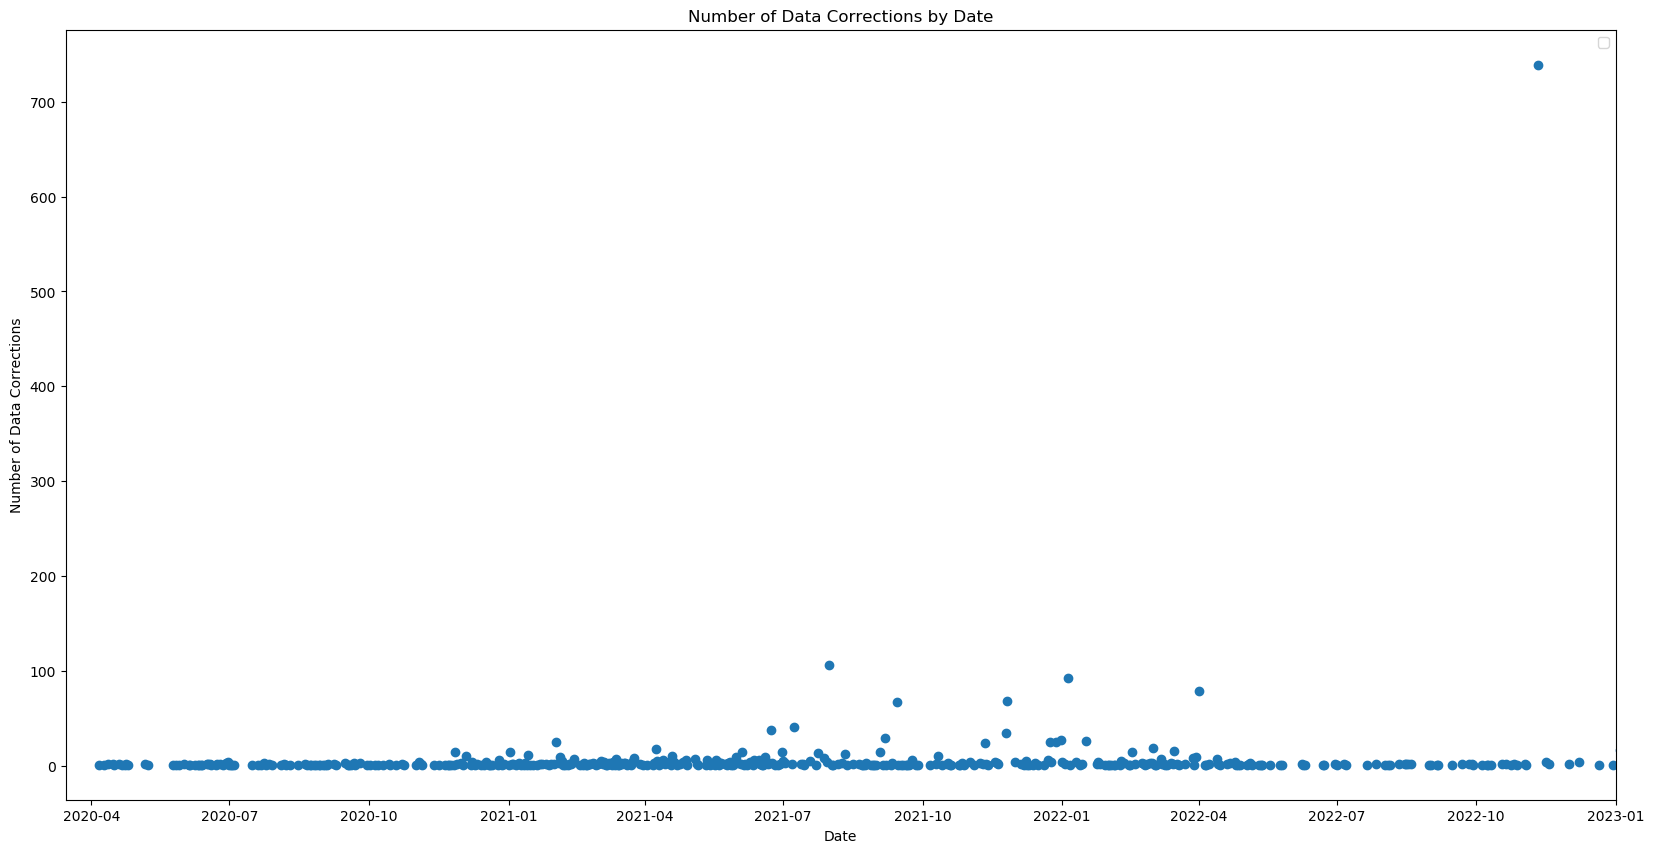

In [14]:
plt.figure(figsize=(20,10))
plt.scatter(x=adjusted_count.index,y=adjusted_count)
plt.xlabel("Date")
plt.ylabel("Number of Data Corrections")
plt.xlim(pd.to_datetime("2020-03-15"), pd.to_datetime("2023-01-01"))
#plt.ylim(0, ylim_dict[metric])
plt.title("Number of Data Corrections by Date")
plt.legend()
#plt.savefig("updated_tcv_ctcv_mae.png")
plt.show()

In [17]:
adjusted_count.groupby(adjusted_count.index.to_period("M")).describe()

,count,mean,std,min,25%,50%,75%,max
date,,,,,,,,
2020-04,10.0,1.400000,0.516398,1.0,1.00,1.0,2.00,2.0
2020-05,5.0,1.200000,0.447214,1.0,1.00,1.0,1.00,2.0
2020-06,18.0,1.611111,0.849837,1.0,1.00,1.0,2.00,4.0
2020-07,11.0,1.272727,0.646670,1.0,1.00,1.0,1.00,3.0
2020-08,13.0,1.153846,0.375534,1.0,1.00,1.0,1.00,2.0
2020-09,14.0,1.571429,0.851631,1.0,1.00,1.0,2.00,3.0
2020-10,9.0,1.222222,0.440959,1.0,1.00,1.0,1.00,2.0
2020-11,13.0,2.384615,3.594868,1.0,1.00,1.0,2.00,14.0
2020-12,18.0,2.388889,2.379790,1.0,1.00,1.0,2.75,10.0


### Load TLGRF

In [6]:
Fixed_windows_MAE_df = pd.read_csv("../benchmark_fixed_window/Fixed_windows_MAE_df.csv")
Fixed_windows_MAE_df["date"] = pd.to_datetime(Fixed_windows_MAE_df["date"])
Fixed_windows_RMSE_df = pd.read_csv("../benchmark_fixed_window/Fixed_windows_RMSE_df.csv")
Fixed_windows_RMSE_df["date"] = pd.to_datetime(Fixed_windows_RMSE_df["date"])

In [ ]:
plt.figure(figsize=(20,10))
plt.scatter(x=adjusted_count.index,y=adjusted_count)
plt.xlabel("Date")
plt.ylabel("Number of Data Corrections")
plt.xlim(pd.to_datetime("2020-03-15"), pd.to_datetime("2023-01-01"))
#plt.ylim(0, ylim_dict[metric])
plt.title("Number of Data Corrections by Date")
plt.legend()
#plt.savefig("updated_tcv_ctcv_mae.png")
plt.show()